# Chopin Op. 30 No. 2 HMM/DTW Debug Run

This notebook trains one HMM for `Chopin_Op030No2` from a single reference recording and 70% of that piece's recordings, then evaluates three held-out recordings. The final plot compares mean absolute alignment error in seconds for Viterbi, streaming DTW, and HMM-influenced streaming DTW against an offline `librosa.sequence.dtw` baseline.

In [47]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [48]:

PIECE_ID = "Chopin_Op030No2"
DATA_DIR = Path("data/wav_22050_mono") / PIECE_ID
TRAIN_FRACTION = 0.70
TEST_RECORDING_COUNT = 3

recording_paths = sorted(DATA_DIR.glob("*.wav"))
reference_path = recording_paths[0]

rng = np.random.default_rng(207)
query_pool = np.array(recording_paths[1:], dtype=object)
shuffled_pool = query_pool[rng.permutation(len(query_pool))]
train_count = int(np.ceil(TRAIN_FRACTION * len(recording_paths))) - 1
train_paths = sorted(shuffled_pool[:train_count])
heldout_paths = sorted(shuffled_pool[train_count:])
test_paths = heldout_paths[:TEST_RECORDING_COUNT]

print(f"reference: {reference_path.name}")
print(f"total recordings: {len(recording_paths)}")
print(f"training recordings: {1 + len(train_paths)} including the reference ({(1 + len(train_paths)) / len(recording_paths):.1%})")
print(f"held-out recordings: {len(heldout_paths)}")
print("test queries:")
for path in test_paths:
    print(f"  {path.name}")

reference: Chopin_Op030No2_Ashkenazy-1981_pid9058-19.wav
total recordings: 34
training recordings: 24 including the reference (70.6%)
held-out recordings: 10
test queries:
  Chopin_Op030No2_Chiu-1999_pid9048-19.wav
  Chopin_Op030No2_Cortot-1951_pid9066-19.wav
  Chopin_Op030No2_Fiorentino-1961_pid9065-14.wav


## Train One Debug HMM

In [49]:
import importlib
import IterativeTrainHMM
importlib.reload(IterativeTrainHMM)

A, Pi, Means, Covars = IterativeTrainHMM.Exec_IterativeTrainHMM(
    str(reference_path),
    [str(path) for path in train_paths],
)

print(f"transition matrix: {A.shape}")
print(f"initial distribution: {Pi.shape}")
print(f"emission states: {len(Means)}")
print(f"feature dim: {Means[0].shape[0]}")

transition matrix: (2990, 2990)
initial distribution: (2990,)
emission states: 2990
feature dim: 12


## Load Reference Features

In [50]:
import librosa
import Constants

reference_audio, sample_rate = librosa.load(reference_path, sr=Constants.DEFAULT_SAMPLE_RATE)
reference_chroma = librosa.feature.chroma_stft(
    y=reference_audio,
    sr=sample_rate,
    hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
)

print(f"reference chroma: {reference_chroma.shape}")

reference chroma: (12, 2990)


## Offline DTW Helpers

In [51]:
def path_to_query_reference_series(path, query_frame_count):
    series = np.full(query_frame_count, np.nan)
    for query_index in range(query_frame_count):
        matching_ref_frames = path[path[:, 1] == query_index, 0]
        if len(matching_ref_frames):
            series[query_index] = np.median(matching_ref_frames)

    valid = np.flatnonzero(~np.isnan(series))
    if len(valid) == 0:
        raise ValueError("DTW path did not cover any query frames")

    missing = np.flatnonzero(np.isnan(series))
    if len(missing):
        series[missing] = np.interp(missing, valid, series[valid])
    return series


def offline_dtw_reference_by_query(reference_chroma, query_chroma):
    _, offline_warping_path = librosa.sequence.dtw(
        X=reference_chroma,
        Y=query_chroma,
        backtrack=True,
    )
    offline_path = offline_warping_path[::-1]
    return path_to_query_reference_series(offline_path, query_chroma.shape[1])

## Evaluate Three Held-Out Recordings

In [94]:
import importlib
import HMMOLTW
import TrainHMM

importlib.reload(HMMOLTW)
importlib.reload(TrainHMM)

SEARCH_HALF_WIDTH = 250
VITERBI_SEARCH_HALF_WIDTH = 75
HMM_STREAMING_DTW_WEIGHT = .5

HMM = HMMOLTW.PreprocessHMMParameters(A, Means, Covars)

def run_streaming_dtw(reference_chroma, query_chroma, search_half_width=SEARCH_HALF_WIDTH):
    reference_state_count = reference_chroma.shape[1]
    streaming_dtw_state = HMMOLTW.InitializeStreamingDTW(reference_state_count)
    viterbi_state = HMMOLTW.InitializeViterbi(TrainHMM.MakeInitialDistribution(reference_state_count))

    estimates = []
    for query_index in range(query_chroma.shape[1]):
        current_reference_estimate, viterbi_state, streaming_dtw_state = HMMOLTW.ProcessNextFrame(
            viterbi_state,
            streaming_dtw_state,
            HMM,
            reference_chroma,
            query_chroma[:, query_index],
            search_half_width,
            0
        )
        estimates.append(current_reference_estimate)
    return np.array(estimates)

def run_viterbi(reference_chroma, query_chroma, search_half_width = VITERBI_SEARCH_HALF_WIDTH):
    reference_state_count = reference_chroma.shape[1]
    
    streaming_dtw_state = HMMOLTW.InitializeStreamingDTW(reference_state_count)
    viterbi_state = HMMOLTW.InitializeViterbi(TrainHMM.MakeInitialDistribution(reference_state_count))

    estimates = []
    for query_index in range(query_chroma.shape[1]):
        current_reference_estimate, viterbi_state, streaming_dtw_state = HMMOLTW.ProcessNextFrame(
            viterbi_state,
            streaming_dtw_state,
            HMM,
            reference_chroma,
            query_chroma[:, query_index],
            search_half_width,
            1
        )
        estimates.append(current_reference_estimate)
    return np.array(estimates)


def run_hmm_influenced_streaming_dtw(
    reference_chroma,
    query_chroma,
    search_half_width=SEARCH_HALF_WIDTH,
):
    reference_state_count = reference_chroma.shape[1]
    
    streaming_dtw_state = HMMOLTW.InitializeStreamingDTW(reference_state_count)
    viterbi_state = HMMOLTW.InitializeViterbi(TrainHMM.MakeInitialDistribution(reference_state_count))

    estimates = []
    for query_index in range(query_chroma.shape[1]):
        current_reference_estimate, viterbi_state, streaming_dtw_state = HMMOLTW.ProcessNextFrame(
            viterbi_state,
            streaming_dtw_state,
            HMM,
            reference_chroma,
            query_chroma[:, query_index],
            search_half_width,
            HMM_STREAMING_DTW_WEIGHT
        )
        estimates.append(current_reference_estimate)
    return np.array(estimates)

c:\Users\morgp\Documents\.HMC\.Year 3\E207\Python\Project\E207DTWHMM\HMMOLTW.py:121: RuntimeWarning: divide by zero encountered in log
  LogTransitionMatrix = np.where(TransitionMatrix > 0, np.log(TransitionMatrix), -np.inf)


In [95]:

def mean_absolute_error_seconds(estimated_reference_by_query, baseline_reference_by_query):
    error_frames = estimated_reference_by_query - baseline_reference_by_query
    error_seconds = error_frames * Constants.DEFAULT_HOP_SIZE_SAMPLES / sample_rate
    return float(np.mean(np.abs(error_seconds)))


def evaluate_test_recording(query_path):
    query_audio, _ = librosa.load(query_path, sr=Constants.DEFAULT_SAMPLE_RATE)
    query_chroma = librosa.feature.chroma_stft(
        y=query_audio,
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )

    offline_reference_by_query = offline_dtw_reference_by_query(reference_chroma, query_chroma)
    streaming_dtw_reference_by_query = run_streaming_dtw(reference_chroma, query_chroma)
    viterbi_reference_by_query = run_viterbi(reference_chroma, query_chroma)
    hmm_streaming_dtw_reference_by_query = run_hmm_influenced_streaming_dtw(
        reference_chroma,
        query_chroma
    )
 
    query_time = librosa.frames_to_time(
        np.arange(query_chroma.shape[1]),
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )

    return {
        "recording": query_path.stem,
        "query_path": query_path,
        "query_time": query_time,
        "offline_reference_by_query": offline_reference_by_query,
        "streaming_dtw_reference_by_query": streaming_dtw_reference_by_query,
        "viterbi_reference_by_query": viterbi_reference_by_query,
        "hmm_streaming_dtw_reference_by_query": hmm_streaming_dtw_reference_by_query,
        "Viterbi": mean_absolute_error_seconds(viterbi_reference_by_query, offline_reference_by_query),
        "Streaming DTW": mean_absolute_error_seconds(streaming_dtw_reference_by_query, offline_reference_by_query),
        "HMM-influenced streaming DTW": mean_absolute_error_seconds(hmm_streaming_dtw_reference_by_query, offline_reference_by_query),
    }


results = []
for query_path in test_paths:
    print(f"evaluating {query_path.name}")
    results.append(evaluate_test_recording(query_path))

for result in results:
    print(result)

evaluating Chopin_Op030No2_Chiu-1999_pid9048-19.wav


c:\Users\morgp\Documents\.HMC\.Year 3\E207\Python\Project\E207DTWHMM\HMMOLTW.py:155: RuntimeWarning: divide by zero encountered in log
  LogPi = np.where(PiFlat > 0, np.log(PiFlat), -np.inf)


evaluating Chopin_Op030No2_Cortot-1951_pid9066-19.wav
evaluating Chopin_Op030No2_Fiorentino-1961_pid9065-14.wav
{'recording': 'Chopin_Op030No2_Chiu-1999_pid9048-19', 'query_path': WindowsPath('data/wav_22050_mono/Chopin_Op030No2/Chopin_Op030No2_Chiu-1999_pid9048-19.wav'), 'query_time': array([0.00000000e+00, 2.32199546e-02, 4.64399093e-02, ...,
       9.16723810e+01, 9.16956009e+01, 9.17188209e+01], shape=(3951,)), 'offline_reference_by_query': array([   0. ,    0. ,    0. , ..., 2986. , 2987.5, 2989. ], shape=(3951,)), 'streaming_dtw_reference_by_query': array([   0,    0,    0, ..., 2834, 2834, 2834], shape=(3951,)), 'viterbi_reference_by_query': array([   0,    0,    0, ..., 2989, 2989, 2989], shape=(3951,)), 'hmm_streaming_dtw_reference_by_query': array([   0,    0,    0, ..., 2911, 2911, 2911], shape=(3951,)), 'Viterbi': 0.23370699228818334, 'Streaming DTW': 0.25058568369556544, 'HMM-influenced streaming DTW': 0.16153765716191143}
{'recording': 'Chopin_Op030No2_Cortot-1951_pid9066

In [54]:
# second_query_path = test_paths[1]
# print(f"evaluating only second recording: {second_query_path.name}")
# second_recording_result = evaluate_test_recording(second_query_path)
# second_recording_result


## Detailed Alignment Path Figures

One separate alignment path figure for each of the three held-out recordings.

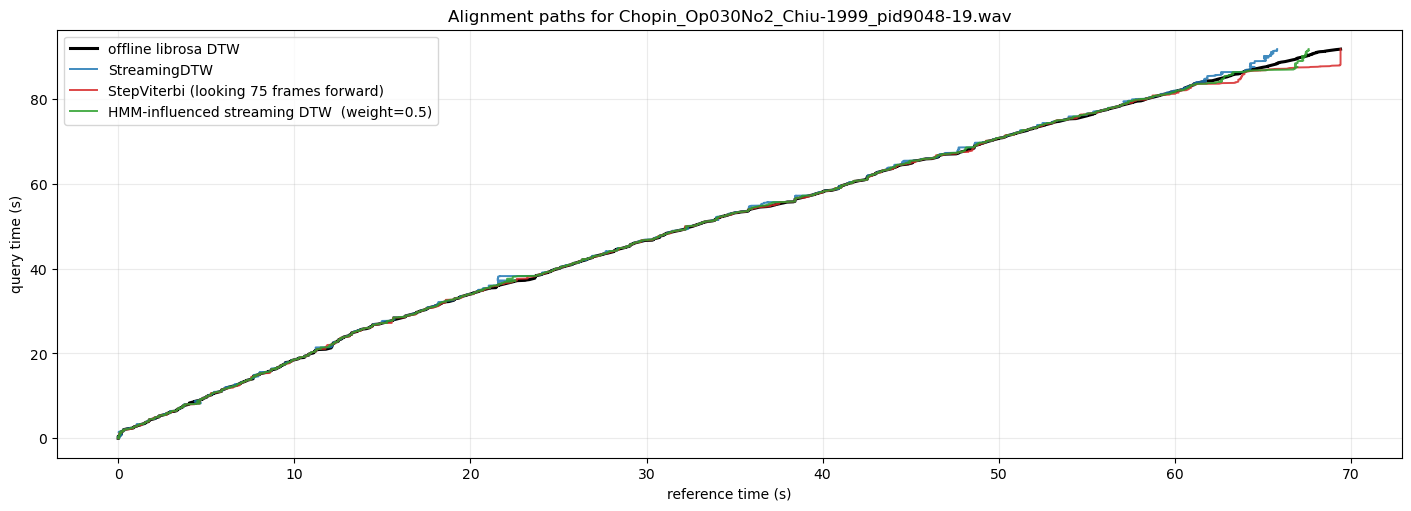

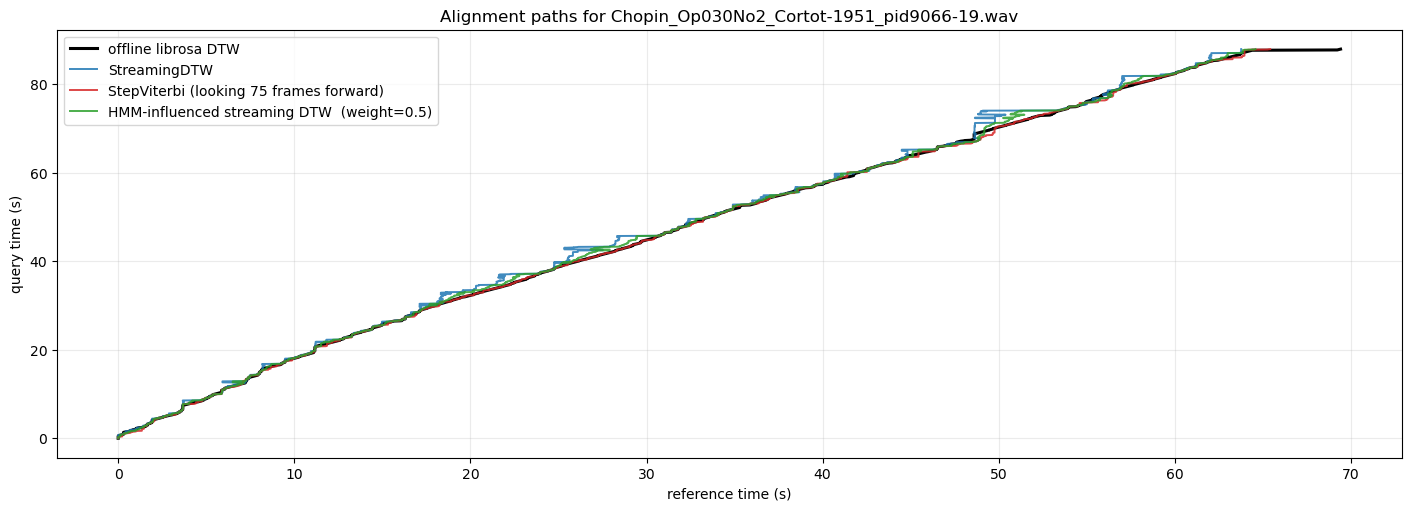

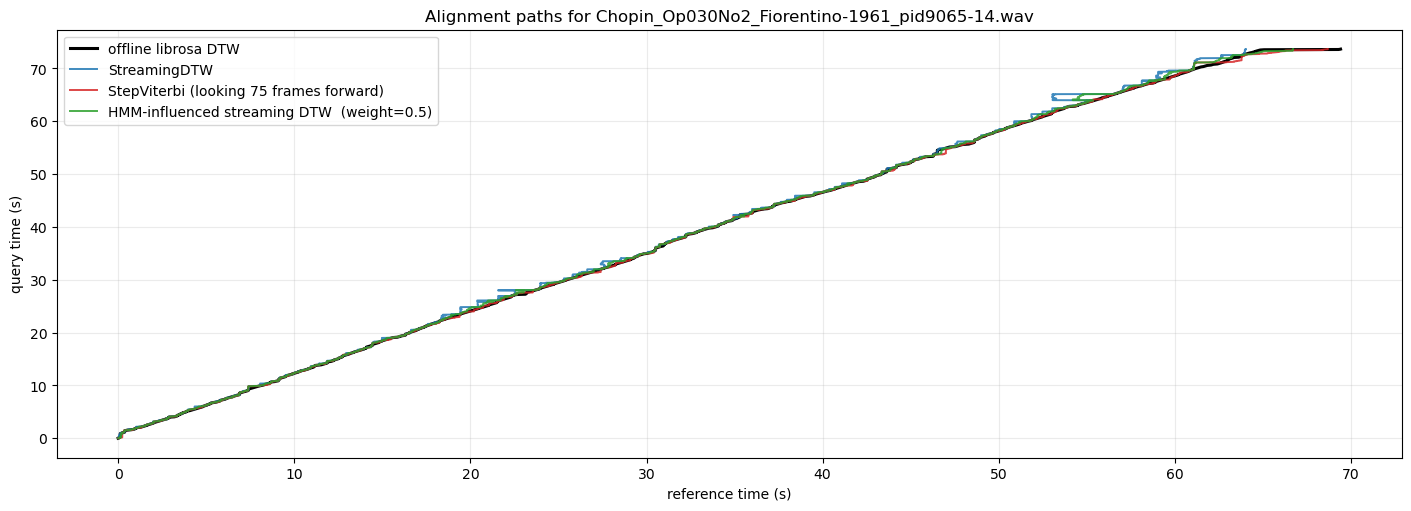

In [96]:
for result in results:
    query_time = result["query_time"]
    reference_time_offline = librosa.frames_to_time(
        result["offline_reference_by_query"],
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )
    reference_time_streaming_dtw = librosa.frames_to_time(
        result["streaming_dtw_reference_by_query"],
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )
    reference_time_viterbi = librosa.frames_to_time(
        result["viterbi_reference_by_query"],
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )
    reference_time_hmm_streaming_dtw = librosa.frames_to_time(
        result["hmm_streaming_dtw_reference_by_query"],
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )

    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
    ax.plot(reference_time_offline, query_time, label="offline librosa DTW", linewidth=2.2, color="black")
    ax.plot(reference_time_streaming_dtw, query_time, label="StreamingDTW", linewidth=1.4, alpha=0.85, color="tab:blue")
    ax.plot(reference_time_viterbi, query_time, label=f"StepViterbi (looking {VITERBI_SEARCH_HALF_WIDTH} frames forward)", linewidth=1.4, alpha=0.85, color="tab:red")
    ax.plot(reference_time_hmm_streaming_dtw, query_time, label=f"HMM-influenced streaming DTW  (weight={HMM_STREAMING_DTW_WEIGHT})", linewidth=1.4, alpha=0.85, color="tab:green")
    ax.set_ylabel("query time (s)")
    ax.set_xlabel("reference time (s)")
    ax.set_title(f"Alignment paths for {result['query_path'].name}")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()

## Mean Absolute Error Summary

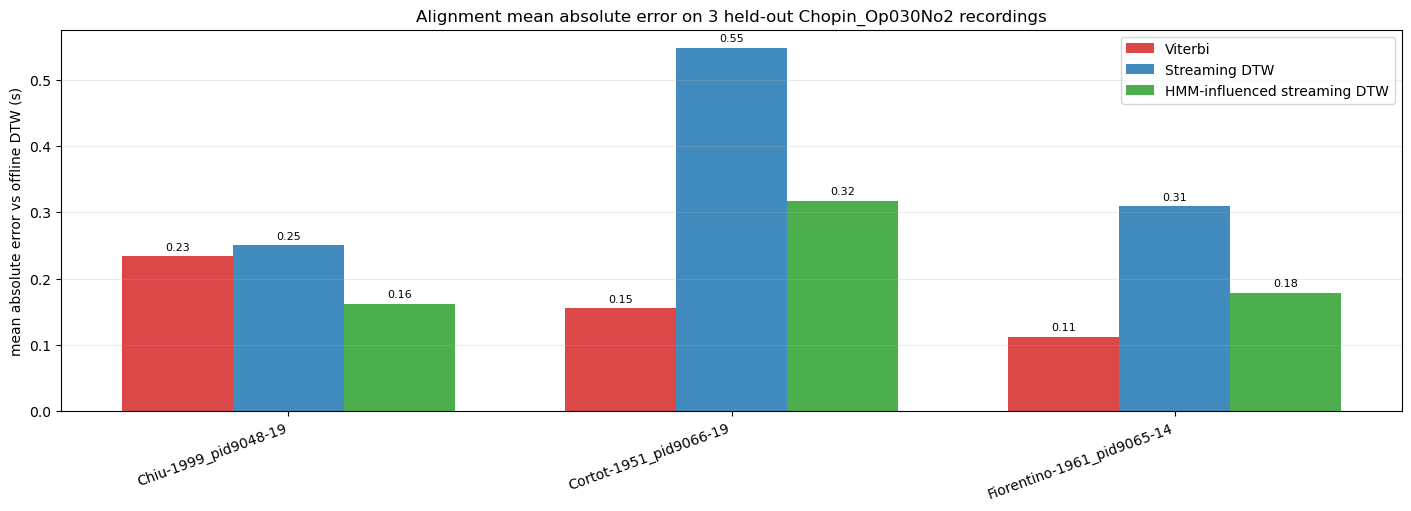

In [97]:
import matplotlib.pyplot as plt

methods = ["Viterbi", "Streaming DTW", "HMM-influenced streaming DTW"]
recording_labels = [result["recording"].replace(f"{PIECE_ID}_", "") for result in results]
mae_matrix = np.array([[result[method] for method in methods] for result in results])

x = np.arange(len(recording_labels))
bar_width = 0.25
colors = ["tab:red", "tab:blue", "tab:green"]

fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)
for method_index, (method, color) in enumerate(zip(methods, colors)):
    offset = (method_index - 1) * bar_width
    bars = ax.bar(x + offset, mae_matrix[:, method_index], width=bar_width, label=method, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(recording_labels, rotation=20, ha="right")
ax.set_ylabel("mean absolute error vs offline DTW (s)")
ax.set_title(f"Alignment mean absolute error on {TEST_RECORDING_COUNT} held-out {PIECE_ID} recordings")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.show()

In [ ]:
def hmm_influenced_streaming_dtw_cost_matrix(query_chroma):
    hmm, viterbi_state, streaming_dtw_state = HMMOLTW.InitializeHMMStreamingDTW(
        reference_chroma,
        A,
        Pi,
        Means,
        Covars,
    )

    cumulative_costs = np.full(
        (query_chroma.shape[1], reference_chroma.shape[1]),
        np.inf,
        dtype=np.float32,
    )
    reference_estimates = []

    for query_frame_index in range(query_chroma.shape[1]):
        reference_estimate, viterbi_state, streaming_dtw_state = HMMOLTW.ProcessNextFrame(
            viterbi_state,
            streaming_dtw_state,
            hmm,
            reference_chroma,
            query_chroma[:, query_frame_index],
            SearchHalfWidth=SEARCH_HALF_WIDTH,
            HMMWeight=HMM_STREAMING_DTW_WEIGHT,
        )
        cumulative_costs[query_frame_index] = streaming_dtw_state.PreviousRowCosts
        reference_estimates.append(reference_estimate)

    return cumulative_costs, np.array(reference_estimates)


for result in results:
    query_chroma, _ = librosa.load(result["query_path"], sr=Constants.DEFAULT_SAMPLE_RATE)
    query_chroma = librosa.feature.chroma_stft(
        y=query_chroma,
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )

    cumulative_costs, hmm_reference_estimates = hmm_influenced_streaming_dtw_cost_matrix(query_chroma)
    display_costs = cumulative_costs.astype(float)
    display_costs[~np.isfinite(display_costs)] = np.nan

    finite_costs = display_costs[np.isfinite(display_costs)]
    vmin, vmax = np.nanpercentile(finite_costs, [2, 98])

    reference_duration = librosa.frames_to_time(
        reference_chroma.shape[1] - 1,
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )
    query_duration = librosa.frames_to_time(
        query_chroma.shape[1] - 1,
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )
    reference_time_hmm = librosa.frames_to_time(
        hmm_reference_estimates,
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )
    query_time = librosa.frames_to_time(
        np.arange(query_chroma.shape[1]),
        sr=sample_rate,
        hop_length=Constants.DEFAULT_HOP_SIZE_SAMPLES,
    )

    fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)
    image = ax.imshow(
        display_costs,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        extent=[0, reference_duration, 0, query_duration],
        vmin=vmin,
        vmax=vmax,
        cmap="magma_r",
    )
    ax.plot(reference_time_hmm, query_time, color="tab:green", linewidth=1.2, label="HMM-influenced streaming DTW path")
    ax.set_xlabel("reference time (s)")
    ax.set_ylabel("query time (s)")
    ax.set_title(f"HMM-influenced streaming DTW cumulative cost matrix for {result['query_path'].name}")
    ax.legend(loc="upper left")
    fig.colorbar(image, ax=ax, label="cumulative cost (2nd-98th percentile clipped)")
    plt.show()

c:\Users\morgp\Documents\.HMC\.Year 3\E207\Python\Project\E207DTWHMM\HMMOLTW.py:121: RuntimeWarning: divide by zero encountered in log
  LogTransitionMatrix = np.where(TransitionMatrix > 0, np.log(TransitionMatrix), -np.inf)
c:\Users\morgp\Documents\.HMC\.Year 3\E207\Python\Project\E207DTWHMM\HMMOLTW.py:155: RuntimeWarning: divide by zero encountered in log
  LogPi = np.where(PiFlat > 0, np.log(PiFlat), -np.inf)


KeyboardInterrupt: 